## Overview

**Part 1: Exploratory Data Analysis (EDA)**
- Load and preview the MNIST Digits and Fashion MNIST datasets.
- Analyze dataset statistics.

**Part 2: Implementing Generative Adversarial Networks (GANs)**
- Build a GAN with a Generator and Discriminator for MNIST digits using TensorFlow.
- Train on MNIST digits and on Fashion MNIST.
- Generate images and plot loss curves.

**Part 3: Implementing Variational Autoencoder (VAE)**
- Build a VAE for MNIST digits using TensorFlow.
- Train the model, visualize the latent space, and generate new images.

**Part 4: Comparison and Analysis**
- Compare GANs vs. VAEs in terms of image quality, training stability, and latent space representation.

**Part 5: Save World (Anomaly Detection)**
- Use the VAE for anomaly detection in a real-world inspired scenario.

**IMPORTING LIBRARIES**

In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


import os
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

print('TensorFlow version:', tf.__version__)
%matplotlib inline

TensorFlow version: 2.10.0


**TENSOR FLOW GPU CHECKING**

In [2]:
gpus = tf.config.experimental.list_physical_devices(device_type="GPU")
tf.config.experimental.set_visible_devices(devices=gpus[0], device_type="GPU")
tf.config.experimental.set_memory_growth(device=gpus[0], enable=True)

In [3]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 6109525049484445870
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 1733715559
locality {
  bus_id: 1
  links {
  }
}
incarnation: 17088377021436356475
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6"
xla_global_id: 416903419
]


In [4]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [5]:
# run this to not get outflow errro 
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)


## Part 1: Exploratory Data Analysis (EDA)

In [158]:
# MNIST Digits
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()

print("MNIST training samples:", x_train_mnist.shape[0])
print("MNIST test samples:", x_test_mnist.shape[0])
print("MNIST classes:", np.unique(y_train_mnist))  

# Fashion MNIST
(x_train_fashion, y_train_fashion), (x_test_fashion, y_test_fashion) = tf.keras.datasets.fashion_mnist.load_data()

print("Fashion MNIST training samples:", x_train_fashion.shape[0])
print("Fashion MNIST test samples:", x_test_fashion.shape[0])
print("Fashion MNIST classes:", np.unique(y_train_fashion))  


#although the labels are numerical just making them relate
fashion_labels = {
    0: "T-shirt/top", 
    1: "Trouser", 
    2: "Pullover", 
    3: "Dress", 
    4: "Coat",
    5: "Sandal", 
    6: "Shirt", 
    7: "Sneaker", 
    8: "Bag", 
    9: "Ankle boot"
}
print("Fashion MNIST label mapping:", fashion_labels)

x_train_mnist = x_train_mnist.astype('float32') / 255.0  # Scale to [0, 1]
x_test_mnist = x_test_mnist.astype('float32') / 255.0


x_train_fashion = (x_train_fashion.astype('float32') / 255.0)
x_test_fashion = (x_test_fashion.astype('float32') / 255.0) 

# Expand dimensions to add a channel dimension add for cnn to work
x_train_mnist = np.expand_dims(x_train_mnist, axis=-1)
x_test_mnist = np.expand_dims(x_test_mnist, axis=-1)

x_train_fashion = np.expand_dims(x_train_fashion, axis=-1)
x_test_fashion = np.expand_dims(x_test_fashion, axis=-1)

print("After expanding dims, MNIST image shape:", x_train_mnist.shape[1:])        #  (28, 28, 1)
print("After expanding dims, Fashion MNIST image shape:", x_train_fashion.shape[1:])  #  (28, 28, 1)


MNIST training samples: 60000
MNIST test samples: 10000
MNIST classes: [0 1 2 3 4 5 6 7 8 9]
Fashion MNIST training samples: 60000
Fashion MNIST test samples: 10000
Fashion MNIST classes: [0 1 2 3 4 5 6 7 8 9]
Fashion MNIST label mapping: {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}
After expanding dims, MNIST image shape: (28, 28, 1)
After expanding dims, Fashion MNIST image shape: (28, 28, 1)


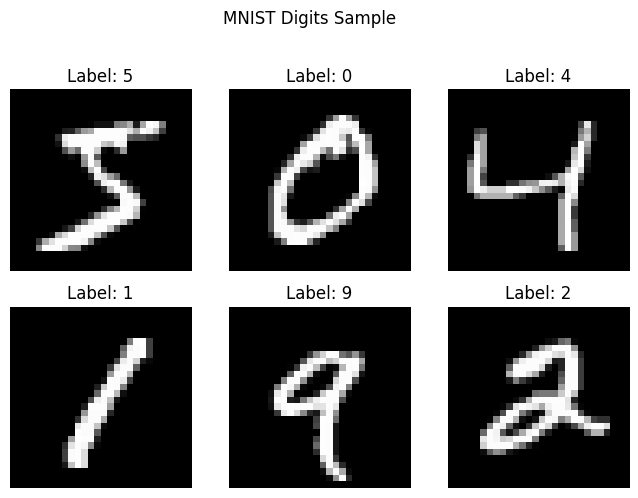

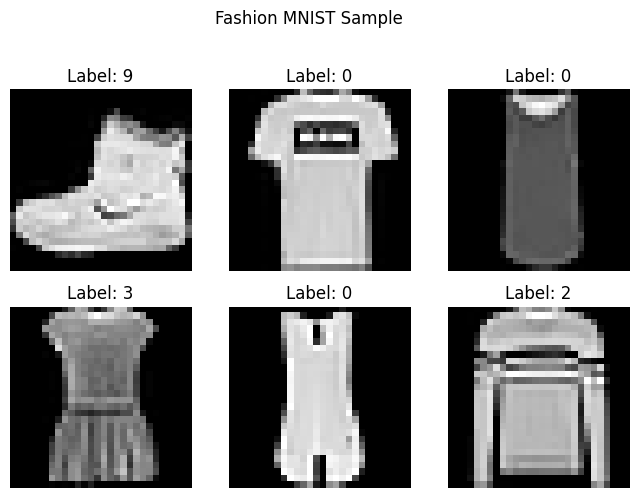

In [7]:
def show_images(images, labels, title, num_images=6):
    plt.figure(figsize=(8, 8))
    for i in range(num_images):
        plt.subplot(3, 3, i+1)
        plt.imshow((images[i].squeeze()), cmap='gray')
        plt.title(f'Label: {labels[i]}')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_images(x_train_mnist, y_train_mnist, 'MNIST Digits Sample')
show_images(x_train_fashion, y_train_fashion, 'Fashion MNIST Sample')

## Part 2: Implementing Generative Adversarial Networks (GANs) using TensorFlow

In [8]:
def build_generator(latent_dim=100):
    model = models.Sequential()
    
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(latent_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Reshape((7, 7, 256)))
    
    # Upsampling: 7x7 -> 14x14
    model.add(layers.Conv2DTranspose(128, kernel_size=5, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))  # Optional dropout
    
    # Upsampling: 14x14 -> 28x28
    model.add(layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))  # Optional dropout
    
    #  for additional depth
    model.add(layers.Conv2DTranspose(32, kernel_size=5, strides=1, padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    
    # Final output layer: 1 channel, sigmoid activation to produce values in [0, 1] same as my image scaling
    model.add(layers.Conv2DTranspose(1, kernel_size=5, strides=1, padding='same', use_bias=False, activation='sigmoid'))
    
    return model

latent_dim = 100
generator = build_generator(latent_dim)
generator.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 12544)             1254400   
                                                                 
 batch_normalization (BatchN  (None, 12544)            50176     
 ormalization)                                                   
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 12544)             0         
                                                                 
 reshape (Reshape)           (None, 7, 7, 256)         0         
                                                                 
 conv2d_transpose (Conv2DTra  (None, 14, 14, 128)      819200    
 nspose)                                                         
                                                                 
 batch_normalization_1 (Batc  (None, 14, 14, 128)      5

In [9]:
def build_discriminator():
    model = models.Sequential()
    
    model.add(layers.Conv2D(64, kernel_size=5, strides=2, padding='same', input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))
  
    model.add(layers.Conv2D(128, kernel_size=5, strides=2, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))
    
    # Third convolution block for deeper features
    model.add(layers.Conv2D(256, kernel_size=5, strides=2, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))
    
    # Flatten and output probability 
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid')) #sigmoid 0/1 for fake or real
    
    return model

discriminator = build_discriminator()
discriminator.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 14, 14, 64)        1664      
                                                                 
 leaky_re_lu_4 (LeakyReLU)   (None, 14, 14, 64)        0         
                                                                 
 dropout_2 (Dropout)         (None, 14, 14, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 7, 7, 128)         204928    
                                                                 
 leaky_re_lu_5 (LeakyReLU)   (None, 7, 7, 128)         0         
                                                                 
 dropout_3 (Dropout)         (None, 7, 7, 128)         0         
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 256)        

### Functions For Images & Graphs

In [10]:
def generate_and_show_images(model, num_images=10):
    noise = tf.random.normal([num_images, latent_dim])
    generated_images = model(noise, training=False)
    # Rescale images to [0,1]
    generated_images = (generated_images + 1.0) / 2.0
    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(5, 5, i+1)
        plt.imshow(generated_images[i, :, :, 0], cmap='gray')
        plt.axis('off')
    plt.suptitle('Generated Images')
    plt.show()

In [11]:
def plot_gan_loss_curves(gan_gen_losses, gan_disc_losses):

    plt.figure(figsize=(10, 5))
    plt.plot(gan_gen_losses, label='Generator Loss')
    plt.plot(gan_disc_losses, label='Discriminator Loss')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('GAN Loss Curves')
    plt.show()


In [12]:
# Loss function and optimizers for GAN
cross_entropy = tf.keras.losses.BinaryCrossentropy()
generator_optimizer = tf.keras.optimizers.Adam(0.0001)
discriminator_optimizer = tf.keras.optimizers.Adam(0.0001)

### Functions For Training GANS

In [13]:
def train_step_gan(images):
    batch_size = tf.shape(images)[0]
    noise = tf.random.normal([batch_size, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Labels: real=1, fake=0
        real_labels = tf.ones_like(real_output)
        fake_labels = tf.zeros_like(fake_output)

        gen_loss = cross_entropy(real_labels, fake_output)
        disc_loss_real = cross_entropy(real_labels, real_output)
        disc_loss_fake = cross_entropy(fake_labels, fake_output)
        disc_loss = disc_loss_real + disc_loss_fake

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    
    return gen_loss, disc_loss

In [14]:
def train_gan_on_dataset(dataset, epochs):

    gan_gen_losses, gan_disc_losses = [], []
    
    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')
        for image_batch in dataset:
            g_loss, d_loss = train_step_gan(image_batch)
            gan_gen_losses.append(g_loss.numpy())
            gan_disc_losses.append(d_loss.numpy())
        print(f'  Generator Loss: {g_loss.numpy():.4f}, Discriminator Loss: {d_loss.numpy():.4f}')
    
    return gan_gen_losses, gan_disc_losses


### Train the GAN on MNIST digits and monitor loss curves

In [16]:
BUFFER_SIZE = 60000
BATCH_SIZE = 128

In [ ]:
mnist_dataset = tf.data.Dataset.from_tensor_slices(x_train_mnist).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

print('Training GAN on MNIST Digits...')
EPOCHS = 5
gan_gen_losses, gan_disc_losses = train_gan_on_dataset(mnist_dataset, EPOCHS)

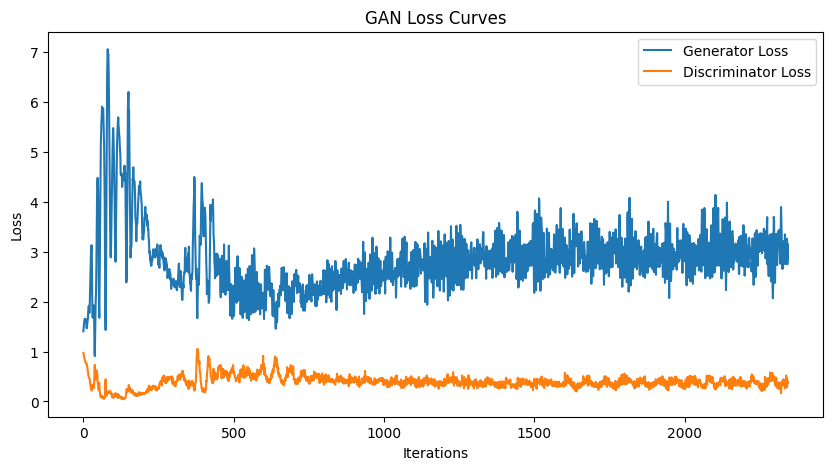

In [ ]:
# Plot GAN loss curves
plot_gan_loss_curves(gan_gen_losses, gan_disc_losses)

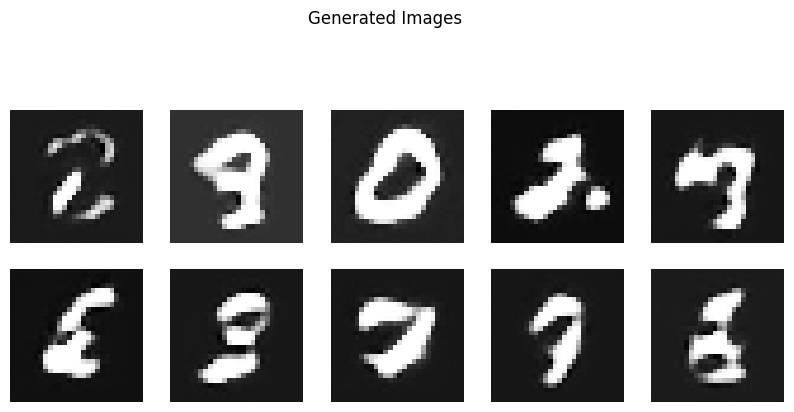

In [ ]:
generate_and_show_images(generator, num_images=10)

### Generate and display 5 newly generated images of RollNumber

In [20]:
cross_entropy = tf.keras.losses.BinaryCrossentropy()
generator_optimizer = tf.keras.optimizers.Adam(0.00001)
discriminator_optimizer = tf.keras.optimizers.Adam(0.00001)

digit = 1
indices = np.where(y_train_mnist == digit)[0]
x_train_digit = x_train_mnist[indices]

discriminator = build_discriminator()
generator = build_generator(latent_dim)

mnist_digit_dataset = tf.data.Dataset.from_tensor_slices(x_train_digit).shuffle(10000).batch(BATCH_SIZE)

print('Training GAN on MNIST Digit 1')
EPOCHS = 20
gan_gen_losses, gan_disc_losses = train_gan_on_dataset(mnist_digit_dataset, EPOCHS)


Training GAN on MNIST Digit 1
Epoch 1/20
  Generator Loss: 0.9224, Discriminator Loss: 1.1593
Epoch 2/20
  Generator Loss: 1.3796, Discriminator Loss: 0.8095
Epoch 3/20
  Generator Loss: 1.9025, Discriminator Loss: 0.4257
Epoch 4/20
  Generator Loss: 2.5763, Discriminator Loss: 0.1924
Epoch 5/20
  Generator Loss: 3.1048, Discriminator Loss: 0.1204
Epoch 6/20
  Generator Loss: 3.2621, Discriminator Loss: 0.1011
Epoch 7/20
  Generator Loss: 2.8072, Discriminator Loss: 0.2513
Epoch 8/20
  Generator Loss: 2.8673, Discriminator Loss: 0.1895
Epoch 9/20
  Generator Loss: 2.8151, Discriminator Loss: 0.2414
Epoch 10/20
  Generator Loss: 2.5276, Discriminator Loss: 0.2503
Epoch 11/20
  Generator Loss: 2.4482, Discriminator Loss: 0.2589
Epoch 12/20
  Generator Loss: 2.2180, Discriminator Loss: 0.3515
Epoch 13/20
  Generator Loss: 2.2980, Discriminator Loss: 0.3550
Epoch 14/20
  Generator Loss: 2.0009, Discriminator Loss: 0.2783
Epoch 15/20
  Generator Loss: 1.9132, Discriminator Loss: 0.3584
Epoc

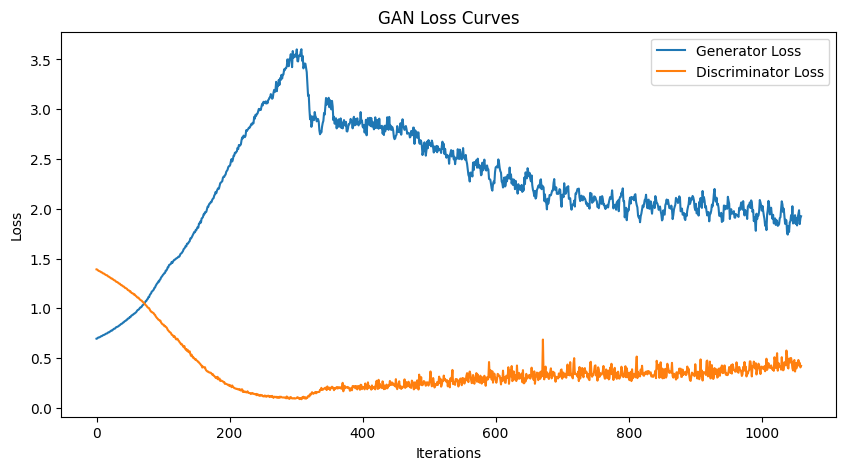

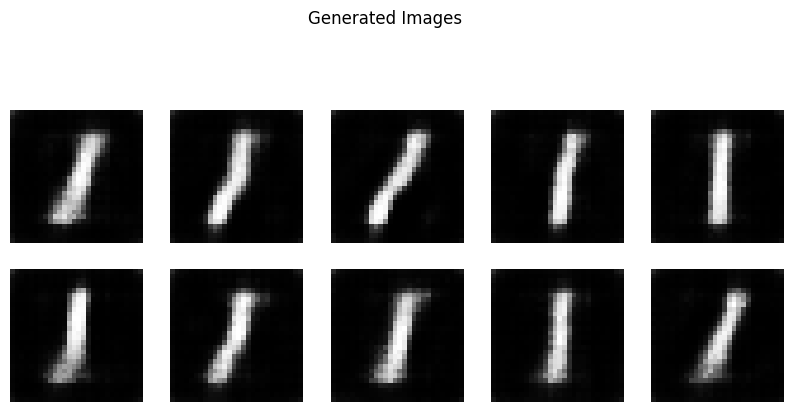

In [21]:
plot_gan_loss_curves(gan_gen_losses, gan_disc_losses)
generate_and_show_images(generator, num_images=10)

### Train the GAN on MNIST Fashion

In [ ]:
# For Fashion MNIST, filter dataset to a specific class (e.g., label 7 for Sneaker)
fashion_indices = np.where(y_train_fashion == 7)[0]
x_train_fashion_sneaker = x_train_fashion[fashion_indices]

fashion_dataset = tf.data.Dataset.from_tensor_slices(x_train_fashion_sneaker).shuffle(10000).batch(BATCH_SIZE)

discriminator = build_discriminator()
generator = build_generator(latent_dim)

print('Training GAN on Fashion MNIST (Sneaker)...')
EPOCHS = 20
gan_gen_losses, gan_disc_losses = train_gan_on_dataset(fashion_dataset, EPOCHS)

Training GAN on Fashion MNIST (Sneaker)...
Epoch 1/20
Generator Loss: 0.6661, Discriminator Loss: 1.1279
Epoch 2/20
Generator Loss: 0.6546, Discriminator Loss: 0.9851
Epoch 3/20
Generator Loss: 0.6098, Discriminator Loss: 0.9962
Epoch 4/20
Generator Loss: 0.8551, Discriminator Loss: 0.8006
Epoch 5/20
Generator Loss: 0.9907, Discriminator Loss: 0.7806
Epoch 6/20
Generator Loss: 1.0301, Discriminator Loss: 0.7817
Epoch 7/20
Generator Loss: 1.0470, Discriminator Loss: 0.8490
Epoch 8/20
Generator Loss: 0.9559, Discriminator Loss: 1.0527
Epoch 9/20
Generator Loss: 0.8893, Discriminator Loss: 1.1105
Epoch 10/20
Generator Loss: 0.8514, Discriminator Loss: 1.1307
Epoch 11/20
Generator Loss: 0.8342, Discriminator Loss: 1.1849
Epoch 12/20
Generator Loss: 0.8427, Discriminator Loss: 1.1750
Epoch 13/20
Generator Loss: 0.8746, Discriminator Loss: 1.1066
Epoch 14/20
Generator Loss: 1.0001, Discriminator Loss: 0.9501
Epoch 15/20
Generator Loss: 1.0049, Discriminator Loss: 1.2064
Epoch 16/20
Generator

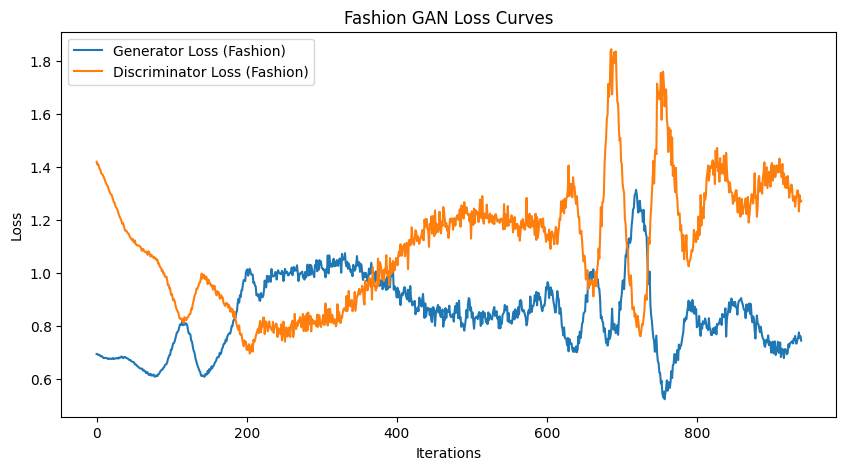

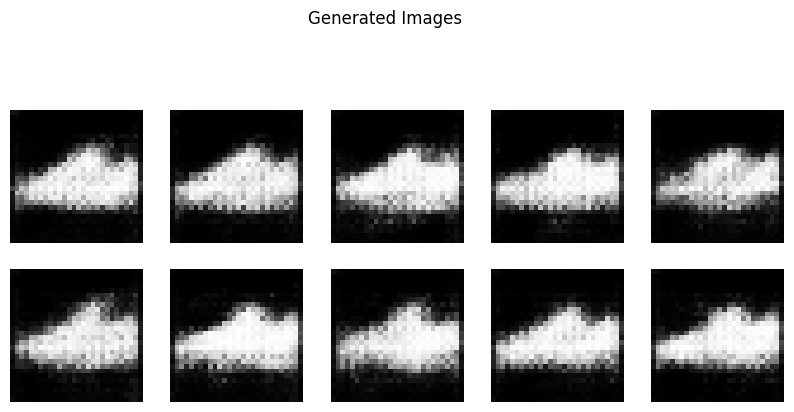

In [ ]:
# Plot Fashion GAN loss curves and generate images
plot_gan_loss_curves(gan_gen_losses, gan_disc_losses)
generate_and_show_images(generator, num_images=10)

## Part 3: Implementing Variational Autoencoder (VAE) using TensorFlow

In [22]:
#clear memory
from tensorflow.keras import backend as K
K.clear_session()


In [13]:
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()
x_train_mnist = x_train_mnist.astype('float32') / 255.0  # Scale to [0, 1]
x_test_mnist = x_test_mnist.astype('float32') / 255.0

# Expand dimensions to add the channel dimension
x_train_mnist = np.expand_dims(x_train_mnist, axis=-1)
x_test_mnist = np.expand_dims(x_test_mnist, axis=-1)

In [160]:
from tensorflow.keras import backend as K

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def build_vae_encoder(latent_dim=20):
    encoder_inputs = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_inputs)
    x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(16, activation='relu')(x)
    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
    return encoder

def build_vae_decoder(latent_dim=20):
    latent_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(7*7*64, activation='relu')(latent_inputs)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
    x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
    decoder_outputs = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    decoder = models.Model(latent_inputs, decoder_outputs, name='decoder')
    return decoder

class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)
        # Compute reconstruction loss and KL divergence
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(tf.keras.losses.binary_crossentropy(inputs, reconstructed), axis=(1,2))
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        self.add_loss(reconstruction_loss + kl_loss)
        return reconstructed

latent_dim = 20
encoder = build_vae_encoder(latent_dim)
decoder = build_vae_decoder(latent_dim)
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())



### Training On MNIST Digits

In [25]:
# Train VAE on MNIST Digits
vae_history = vae.fit(x_train_mnist, x_train_mnist, epochs=20, batch_size=128, validation_data=(x_test_mnist, x_test_mnist))

Epoch 1/20
469/469 [==============================] - 9s 16ms/step - loss: 208.5401 - val_loss: 168.7112
Epoch 2/20
469/469 [==============================] - 7s 15ms/step - loss: 157.8185 - val_loss: 149.8303
Epoch 3/20
469/469 [==============================] - 7s 16ms/step - loss: 146.2538 - val_loss: 143.0119
Epoch 4/20
469/469 [==============================] - 8s 16ms/step - loss: 141.5686 - val_loss: 139.6132
Epoch 5/20
469/469 [==============================] - 8s 17ms/step - loss: 138.8072 - val_loss: 138.0020
Epoch 6/20
469/469 [==============================] - 8s 17ms/step - loss: 137.1057 - val_loss: 136.3869
Epoch 7/20
469/469 [==============================] - 8s 18ms/step - loss: 135.7831 - val_loss: 135.4049
Epoch 8/20
469/469 [==============================] - 8s 18ms/step - loss: 134.7047 - val_loss: 134.3821
Epoch 9/20
469/469 [==============================] - 8s 18ms/step - loss: 133.8452 - val_loss: 133.8402
Epoch 10/20
469/469 [==============================] - 

#### Extract and visualize the latent space representation using t-SNE/PCA

32/32 [==============================] - 0s 3ms/step


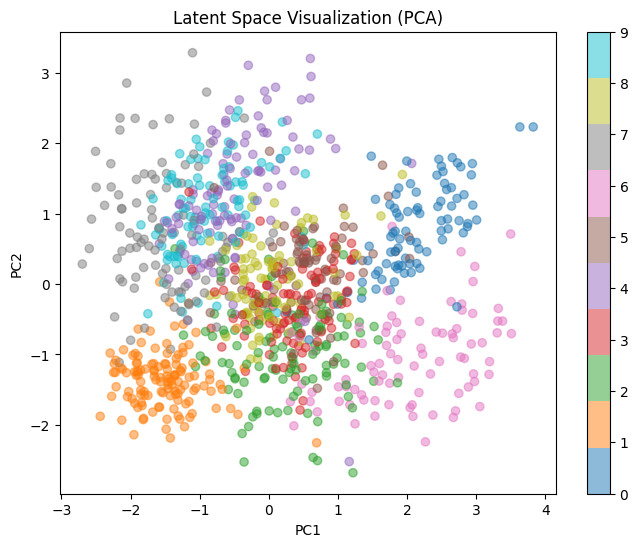

In [26]:
# Visualize the latent space using the encoder and PCA
def visualize_latent_space(encoder, data, labels, num_samples=1000):
    z_mean, _, _ = encoder.predict(data[:num_samples])
    pca = PCA(n_components=2)
    z_pca = pca.fit_transform(z_mean)
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(z_pca[:, 0], z_pca[:, 1], c=labels[:num_samples], cmap='tab10', alpha=0.5)
    plt.colorbar(scatter)
    plt.title('Latent Space Visualization (PCA)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()

visualize_latent_space(encoder, x_test_mnist, y_test_mnist)

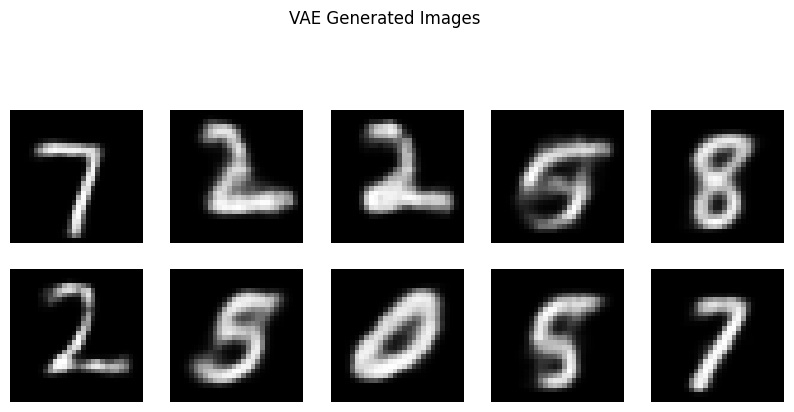

In [29]:
# Generate images using the VAE decoder by sampling latent vectors
def generate_vae_images(decoder, num_images=10, latent_dim=20):
    random_latent_vectors = tf.random.normal(shape=(num_images, latent_dim))
    generated_images = decoder(random_latent_vectors)
    # Rescale for display if needed
    generated_images = (generated_images * 255).numpy().astype('uint8')
    plt.figure(figsize=(10,10))
    for i in range(num_images):
        plt.subplot(5, 5, i+1)
        plt.imshow(generated_images[i, :, :, 0], cmap='gray')
        plt.axis('off')
    plt.suptitle('VAE Generated Images')
    plt.show()

generate_vae_images(decoder, num_images=10, latent_dim=latent_dim)

In [ ]:
def generate_specific_digit(decoder, stored_latent, num_images=5, noise_std=0.1):

    latent_vector = tf.convert_to_tensor(stored_latent, dtype=tf.float32)
    latent_vector = tf.expand_dims(latent_vector, axis=0)  # Now shape is (1, latent_dim)
    
    generated_images = []
    for _ in range(num_images):
        # Add a small amount of noise to the latent vector to generate a varied output.
        noise = tf.random.normal(shape=tf.shape(latent_vector), mean=0.0, stddev=noise_std)
        modified_latent = latent_vector + noise
        # Use the decoder to generate an image from the modified latent vector.
        gen_image = decoder(modified_latent, training=False)
        generated_images.append(gen_image)
    
    # Concatenate generated images along the batch dimension.
    generated_images = tf.concat(generated_images, axis=0)
    return generated_images

In [42]:
def display_generated_images(images, title="Generated Images"):
    plt.figure(figsize=(10, 10))
    num_images = 5
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i, :, :, 0], cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

1/1 [==============================] - 0s 15ms/step


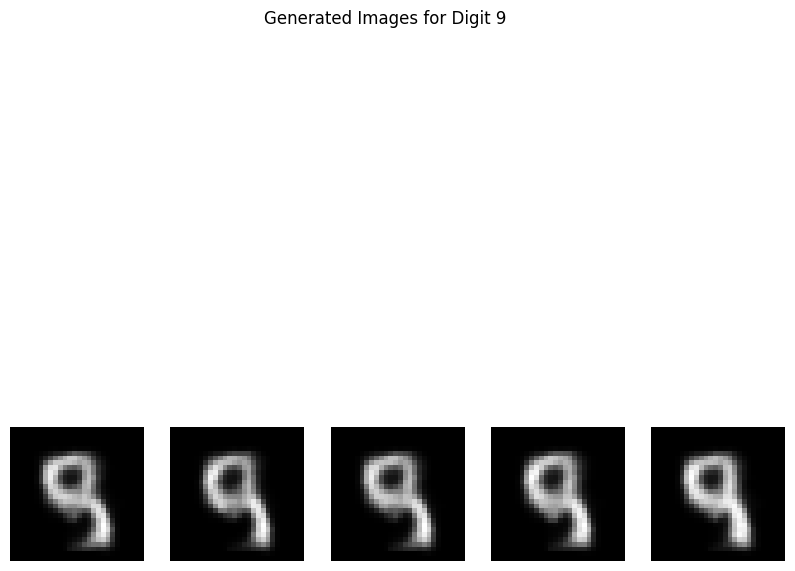

In [ ]:
digit = 9
# Find indices of test images corresponding to the chosen digit

digit_indices = np.where(y_test_mnist == digit)[0]
if len(digit_indices) == 0:
    raise ValueError(f"No images found for digit {digit}")

sample_image = x_test_mnist[digit_indices[0]]
sample_image = np.expand_dims(sample_image, axis=0)  # shape becomes (1, 28, 28, 1)

z_mean, z_log_var, z = encoder.predict(sample_image)
stored_latent_vector = z_mean[0]  # stored_latent_vector is now of shape (latent_dim,)
generated_imgs = generate_specific_digit(decoder, stored_latent_vector, num_images=5, noise_std=0.1)

# Display the generated images
display_generated_images(generated_imgs, title=f"Generated Images for Digit {digit}")


### Training on MNIST Fashion

In [161]:
# Train VAE on MNIST Digits
vae_history = vae.fit(x_train_fashion, x_train_fashion, epochs=20, batch_size=128, validation_data=(x_test_fashion, x_test_fashion))

Epoch 1/20
469/469 [==============================] - 10s 18ms/step - loss: 336.1229 - val_loss: 300.5413
Epoch 2/20
469/469 [==============================] - 9s 20ms/step - loss: 293.5064 - val_loss: 290.0509
Epoch 3/20
469/469 [==============================] - 10s 21ms/step - loss: 285.0858 - val_loss: 282.7691
Epoch 4/20
469/469 [==============================] - 10s 21ms/step - loss: 279.3357 - val_loss: 278.0517
Epoch 5/20
469/469 [==============================] - 10s 21ms/step - loss: 275.5929 - val_loss: 275.3348
Epoch 6/20
469/469 [==============================] - 11s 23ms/step - loss: 273.1279 - val_loss: 273.4310
Epoch 7/20
469/469 [==============================] - 12s 25ms/step - loss: 271.4328 - val_loss: 273.5297
Epoch 8/20
469/469 [==============================] - 13s 27ms/step - loss: 270.2269 - val_loss: 271.6046
Epoch 9/20
469/469 [==============================] - 13s 27ms/step - loss: 269.3374 - val_loss: 270.6581
Epoch 10/20
469/469 [==========================

32/32 [==============================] - 0s 2ms/step


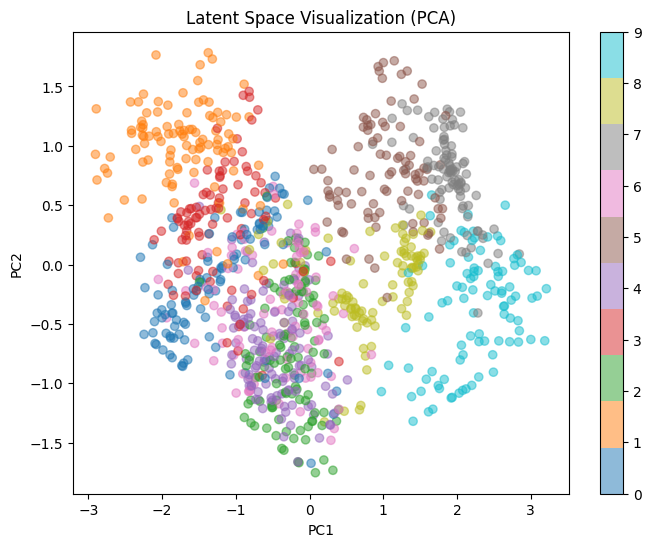

In [162]:
visualize_latent_space(encoder, x_test_fashion, y_test_fashion)

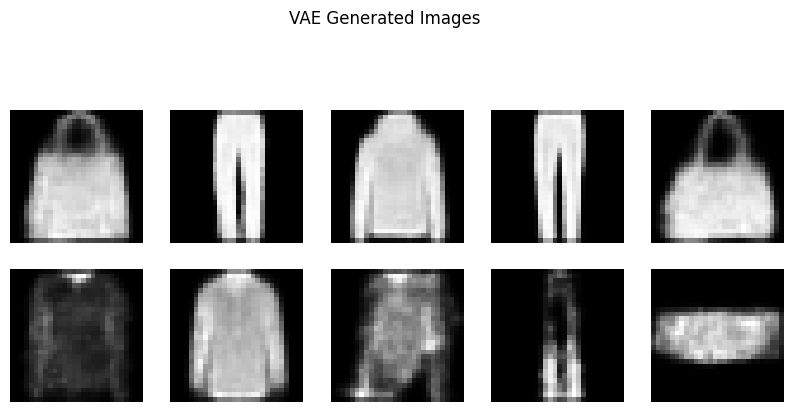

In [50]:
generate_vae_images(decoder, num_images=10, latent_dim=latent_dim)

1/1 [==============================] - 0s 21ms/step


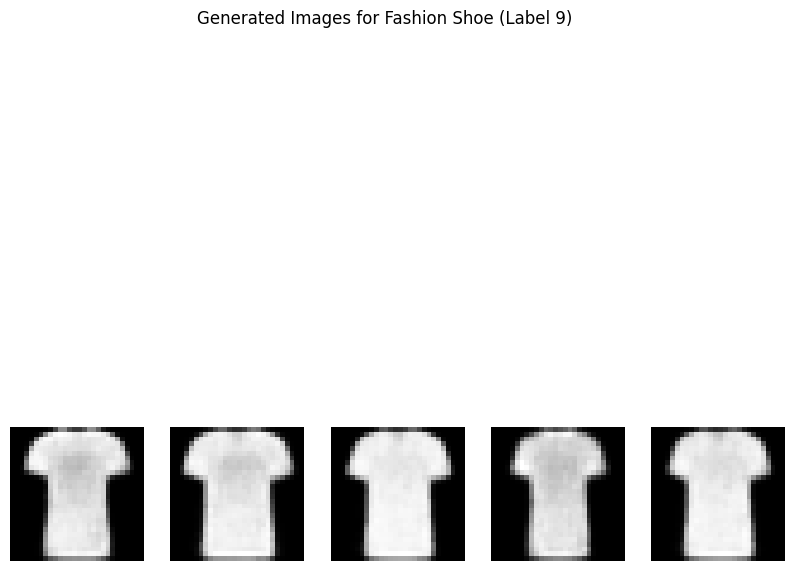

In [53]:

digit_indices = np.where(y_test_fashion == 0)[0]
if len(digit_indices) == 0:
    raise ValueError(f"No images found for label {digit}")

sample_image = x_test_fashion[digit_indices[0]]
sample_image = np.expand_dims(sample_image, axis=0)  # Now shape is (1, 28, 28, 1)

z_mean, z_log_var, z = encoder.predict(sample_image)
stored_latent_vector = z_mean[0]  # stored_latent_vector is now of shape (latent_dim,)

generated_imgs = generate_specific_digit(decoder, stored_latent_vector, num_images=5, noise_std=0.3)
display_generated_images(generated_imgs, title=f"Generated Images for Fashion Shoe (Label {digit})")


## Part 4: Comparison and Analysis

- **IN REPORT** 

## Part 5: Save World with VAE (Anomaly Detection)

Anomaly detection can lead to significant financial savings (e.g., detecting fraudulent transactions or equipment failures). In this section, you should:

1. Choose a dataset with normal and anomalous instances.
2. Train the VAE on normal data only.
3. Compute reconstruction errors on the test set.
4. Define a threshold to flag anomalies.


In [142]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
data_path = tf.keras.utils.get_file("creditcard.csv", dataset_url)

data = pd.read_csv(data_path)

In [143]:
# We'll drop the 'Time' col
X = data.drop(columns=['Class', 'Time'])
y = data['Class'].values

In [144]:
unique_labels, counts = np.unique(y, return_counts=True)
for label, count in zip(unique_labels, counts):
    print(f"Label {label}: {count}")


#0.00173047500131895960466384116209 percent of anomalous transactions

Label 0: 284315
Label 1: 492


In [145]:
# Normalize features to [0, 1] using MinMaxScaler.
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [146]:
# For VAE training, we use only normal transactions as defined in the requiremnets
normal_indices = np.where(y == 0)[0]
X_train_normal = X_scaled[normal_indices]
print(f"Training on {X_train_normal.shape[0]} normal transactions.")

Training on 284315 normal transactions.


In [147]:
# use the entire dataset as test set.
X_test = X_scaled

input_dim = X_scaled.shape[1]
latent_dim = 10  

In [148]:
def build_tabular_encoder(input_dim, latent_dim):
    encoder_inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(32, activation='relu')(encoder_inputs)
    x = layers.Dense(16, activation='relu')(x)
    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
    
    # Sampling layer using Lambda
    def sampling(args):
        z_mean, z_log_var = args
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon
    z = layers.Lambda(sampling, name='z')([z_mean, z_log_var])
    
    encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
    return encoder

In [149]:
def build_tabular_decoder(input_dim, latent_dim):
    latent_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(16, activation='relu')(latent_inputs)
    x = layers.Dense(32, activation='relu')(x)
    # Use sigmoid activation because the inputs are scaled to [0, 1]
    decoder_outputs = layers.Dense(input_dim, activation='sigmoid')(x)
    decoder = models.Model(latent_inputs, decoder_outputs, name='decoder')
    return decoder

encoder = build_tabular_encoder(input_dim, latent_dim)
decoder = build_tabular_decoder(input_dim, latent_dim)

In [150]:
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        # Instead of summing over axis=1 we directly compute the binary crossentropy loss, which returns a tensor of shape (batch_size,)
        reconstruction_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(inputs, reconstruction)
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        self.add_loss(reconstruction_loss + kl_loss)
        return reconstruction

In [151]:
def detect_anomalies(vae, X_data, X_train_normal, threshold=None):
    reconstructions = vae.predict(X_data)
    errors = np.mean(np.square(X_data - reconstructions), axis=1)
    
    # Compute reconstruction errors on normal training data
    train_recons = vae.predict(X_train_normal)
    train_errors = np.mean(np.square(X_train_normal - train_recons), axis=1)
    
    if threshold is None:
        threshold = np.percentile(train_errors, 95)
        print(threshold)
    
    anomaly_flags = errors > threshold
    return errors, anomaly_flags, threshold

In [152]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())

In [153]:
# Train the VAE on Normal Transactions Only
epochs = 10
batch_size = 128

history = vae.fit(X_train_normal, X_train_normal,
                  epochs=epochs,
                  batch_size=batch_size,
                  validation_split=0.1,
                  verbose=2)

Epoch 1/10
2000/2000 - 11s - loss: 0.5972 - val_loss: 0.5902 - 11s/epoch - 6ms/step
Epoch 2/10
2000/2000 - 10s - loss: 0.5917 - val_loss: 0.5901 - 10s/epoch - 5ms/step
Epoch 3/10
2000/2000 - 10s - loss: 0.5917 - val_loss: 0.5901 - 10s/epoch - 5ms/step
Epoch 4/10
2000/2000 - 10s - loss: 0.5917 - val_loss: 0.5902 - 10s/epoch - 5ms/step
Epoch 5/10
2000/2000 - 10s - loss: 0.5917 - val_loss: 0.5901 - 10s/epoch - 5ms/step
Epoch 6/10
2000/2000 - 10s - loss: 0.5917 - val_loss: 0.5902 - 10s/epoch - 5ms/step
Epoch 7/10
2000/2000 - 10s - loss: 0.5917 - val_loss: 0.5902 - 10s/epoch - 5ms/step
Epoch 8/10
2000/2000 - 10s - loss: 0.5917 - val_loss: 0.5902 - 10s/epoch - 5ms/step
Epoch 9/10
2000/2000 - 10s - loss: 0.5917 - val_loss: 0.5902 - 10s/epoch - 5ms/step
Epoch 10/10
2000/2000 - 10s - loss: 0.5917 - val_loss: 0.5902 - 10s/epoch - 5ms/step


In [154]:
errors, anomaly_flags, threshold = detect_anomalies(vae, X_test, X_train_normal, 0.0035)
print(f"Anomaly threshold: {threshold:.4f}")
print(f"Total test samples: {len(X_test)}")
print(f"Detected anomalies: {np.sum(anomaly_flags)}")


8885/8885 [==============================] - 19s 2ms/step
Anomaly threshold: 0.0035
Total test samples: 284807
Detected anomalies: 14723


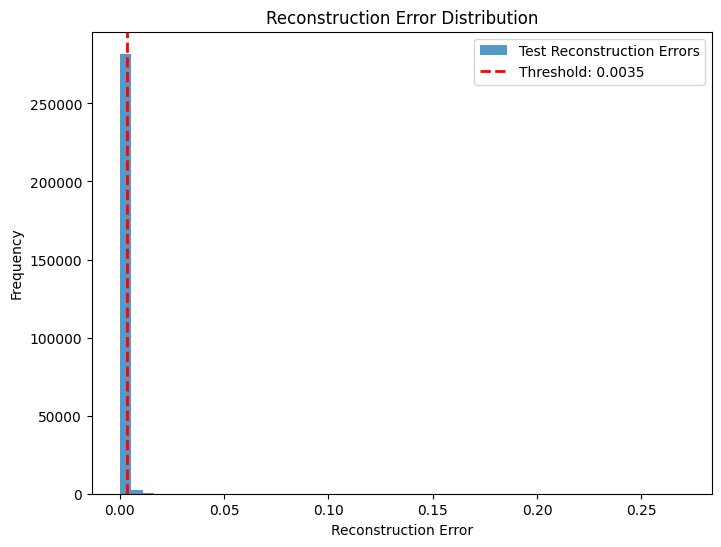

In [155]:
# Visualize Reconstruction Error Distribution

plt.figure(figsize=(8,6))
plt.hist(errors, bins=50, alpha=0.75, label='Test Reconstruction Errors')
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'Threshold: {threshold:.4f}')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.legend()
plt.title('Reconstruction Error Distribution')
plt.show()

In [156]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

def evaluate_anomaly_detection(y_true, anomaly_flags, errors=None):
    y_pred = anomaly_flags.astype(int)
    precision = precision_score(y_true, y_pred, pos_label=1)
    recall    = recall_score(y_true, y_pred, pos_label=1)
    f1        = f1_score(y_true, y_pred, pos_label=1)
    
    if errors is not None:
        auc = roc_auc_score(y_true, errors)
    else:
        auc = None
    
    # Print results
    print("=== Anomaly Detection Evaluation ===")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    if auc is not None:
        print(f"AUC:       {auc:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"]))
    
    results = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc': auc
    }
    return results


metrics = evaluate_anomaly_detection(y, anomaly_flags, errors=errors)


=== Anomaly Detection Evaluation ===
Precision: 0.0283
Recall:    0.8476
F1-score:  0.0548
AUC:       0.9476

Confusion Matrix:
[[270009  14306]
 [    75    417]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97    284315
     Anomaly       0.03      0.85      0.05       492

    accuracy                           0.95    284807
   macro avg       0.51      0.90      0.51    284807
weighted avg       1.00      0.95      0.97    284807

